In [1]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

baseline_features = np.load('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/data/baseline_features.npy')
base_features = np.load('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/data/brainomni_features_base.npy')
tiny_features = np.load('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/data/brainomni_features_tiny.npy')

labels = np.load('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/data/labels.npy')

In [2]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

y_true = []
y_pred_baseline = []
y_pred_tiny     = []
y_pred_base     = []

baseline_fold_scores = []
tiny_fold_scores     = []
base_fold_scores     = []

for train_idx, test_idx in cv.split(baseline_features, labels):

    # --- Baseline ---
    clf = LogisticRegression(max_iter=1000)
    clf.fit(baseline_features[train_idx], labels[train_idx])
    preds = clf.predict(baseline_features[test_idx])
    y_pred_baseline.extend(preds)
    baseline_fold_scores.append(accuracy_score(labels[test_idx], preds))

    # --- BrainOmni-tiny ---
    pca = PCA(n_components=50)
    X_train = pca.fit_transform(tiny_features[train_idx])
    X_test  = pca.transform(tiny_features[test_idx])
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, labels[train_idx])
    preds = clf.predict(X_test)
    y_pred_tiny.extend(preds)
    tiny_fold_scores.append(accuracy_score(labels[test_idx], preds))

    # --- BrainOmni-base ---
    pca = PCA(n_components=50)
    X_train = pca.fit_transform(base_features[train_idx])
    X_test  = pca.transform(base_features[test_idx])
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, labels[train_idx])
    preds = clf.predict(X_test)
    y_pred_base.extend(preds)
    base_fold_scores.append(accuracy_score(labels[test_idx], preds))

    y_true.extend(labels[test_idx])

print('======== Baseline ========')
print(classification_report(y_true, y_pred_baseline, target_names=['Control', 'AD']))

print('======== BrainOmni-tiny ========')
print(classification_report(y_true, y_pred_tiny, target_names=['Control', 'AD']))

print('======== BrainOmni-base ========')
print(classification_report(y_true, y_pred_base, target_names=['Control', 'AD']))

======== Baseline ========
              precision    recall  f1-score   support

     Control       0.84      0.90      0.87        70
          AD       0.90      0.85      0.87        78

    accuracy                           0.87       148
   macro avg       0.87      0.87      0.87       148
weighted avg       0.87      0.87      0.87       148

======== BrainOmni-tiny ========
              precision    recall  f1-score   support

     Control       0.83      0.81      0.82        70
          AD       0.84      0.85      0.84        78

    accuracy                           0.83       148
   macro avg       0.83      0.83      0.83       148
weighted avg       0.83      0.83      0.83       148

======== BrainOmni-base ========
              precision    recall  f1-score   support

     Control       0.83      0.81      0.82        70
          AD       0.84      0.85      0.84        78

    accuracy                           0.83       148
   macro avg       0.83      0.83  

In [3]:
baseline_fold_scores = np.array(baseline_fold_scores)
tiny_fold_scores     = np.array(tiny_fold_scores)
base_fold_scores     = np.array(base_fold_scores)

print(f'Baseline       accuracy per fold: {baseline_fold_scores.round(3)}')
print(f'Baseline       mean accuracy:      {baseline_fold_scores.mean():.3f}')
print()
print(f'BrainOmni-tiny accuracy per fold: {tiny_fold_scores.round(3)}')
print(f'BrainOmni-tiny mean accuracy:      {tiny_fold_scores.mean():.3f}')
print()
print(f'BrainOmni-base accuracy per fold: {base_fold_scores.round(3)}')
print(f'BrainOmni-base mean accuracy:      {base_fold_scores.mean():.3f}')

Baseline       accuracy per fold: [0.833 0.867 0.9   0.862 0.897]
Baseline       mean accuracy:      0.872

BrainOmni-tiny accuracy per fold: [0.633 0.967 0.9   0.828 0.828]
BrainOmni-tiny mean accuracy:      0.831

BrainOmni-base accuracy per fold: [0.633 0.967 0.9   0.828 0.828]
BrainOmni-base mean accuracy:      0.831


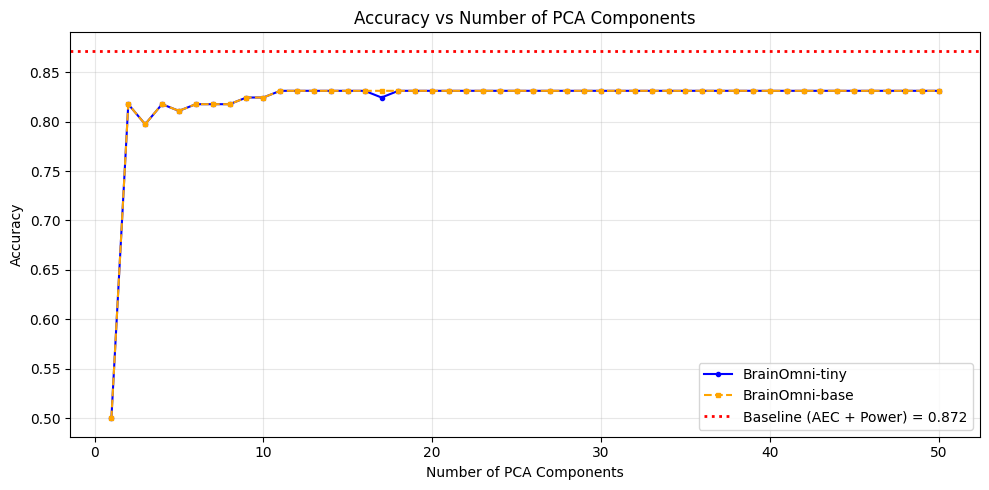

Saved to /Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/pca_sweep.png


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

pca_range = range(1, 51)
tiny_accs = []
base_accs = []

for n in pca_range:
    y_pred_tiny_n = []
    y_pred_base_n = []
    y_true_n = []

    for train_idx, test_idx in cv.split(tiny_features, labels):

        # BrainOmni-tiny
        pca = PCA(n_components=n)
        X_train = pca.fit_transform(tiny_features[train_idx])
        X_test  = pca.transform(tiny_features[test_idx])
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, labels[train_idx])
        y_pred_tiny_n.extend(clf.predict(X_test))

        # BrainOmni-base
        pca = PCA(n_components=n)
        X_train = pca.fit_transform(base_features[train_idx])
        X_test  = pca.transform(base_features[test_idx])
        clf = LogisticRegression(max_iter=1000)
        clf.fit(X_train, labels[train_idx])
        y_pred_base_n.extend(clf.predict(X_test))

        y_true_n.extend(labels[test_idx])

    tiny_accs.append(accuracy_score(y_true_n, y_pred_tiny_n))
    base_accs.append(accuracy_score(y_true_n, y_pred_base_n))

baseline_acc = accuracy_score(y_true, y_pred_baseline)

plt.figure(figsize=(10, 5))
plt.plot(pca_range, tiny_accs, label='BrainOmni-tiny', color='blue', linestyle='-', marker='o', markersize=3)
plt.plot(pca_range, base_accs, label='BrainOmni-base', color='orange', linestyle='--', marker='s', markersize=3)
plt.axhline(y=baseline_acc, color='red', linestyle=':', linewidth=2, label=f'Baseline (AEC + Power) = {baseline_acc:.3f}')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Number of PCA Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_path = '/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/pca_sweep.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved to {save_path}')

In [5]:
from sklearn.ensemble import GradientBoostingClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

y_true_gb = []
y_pred_baseline_gb  = []
y_pred_tiny_gb      = []
y_pred_base_gb      = []

for train_idx, test_idx in cv.split(baseline_features, labels):

    # --- Baseline ---
    clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=123)
    clf.fit(baseline_features[train_idx], labels[train_idx])
    y_pred_baseline_gb.extend(clf.predict(baseline_features[test_idx]))

    # --- BrainOmni-tiny ---
    pca = PCA(n_components=50)
    X_train = pca.fit_transform(tiny_features[train_idx])
    X_test  = pca.transform(tiny_features[test_idx])
    clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=123)
    clf.fit(X_train, labels[train_idx])
    y_pred_tiny_gb.extend(clf.predict(X_test))

    # --- BrainOmni-base ---
    pca = PCA(n_components=50)
    X_train = pca.fit_transform(base_features[train_idx])
    X_test  = pca.transform(base_features[test_idx])
    clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=123)
    clf.fit(X_train, labels[train_idx])
    y_pred_base_gb.extend(clf.predict(X_test))

    y_true_gb.extend(labels[test_idx])

print('======== Gradient Boosting 5-fold ========')
print('Baseline:')
print(classification_report(y_true_gb, y_pred_baseline_gb, target_names=['Control', 'AD']))
print('BrainOmni-tiny:')
print(classification_report(y_true_gb, y_pred_tiny_gb, target_names=['Control', 'AD']))
print('BrainOmni-base:')
print(classification_report(y_true_gb, y_pred_base_gb, target_names=['Control', 'AD']))

======== Gradient Boosting 5-fold ========
Baseline:
              precision    recall  f1-score   support

     Control       0.78      0.87      0.82        70
          AD       0.87      0.78      0.82        78

    accuracy                           0.82       148
   macro avg       0.83      0.83      0.82       148
weighted avg       0.83      0.82      0.82       148

BrainOmni-tiny:
              precision    recall  f1-score   support

     Control       0.80      0.80      0.80        70
          AD       0.82      0.82      0.82        78

    accuracy                           0.81       148
   macro avg       0.81      0.81      0.81       148
weighted avg       0.81      0.81      0.81       148

BrainOmni-base:
              precision    recall  f1-score   support

     Control       0.80      0.81      0.81        70
          AD       0.83      0.82      0.83        78

    accuracy                           0.82       148
   macro avg       0.82      0.82      0.82

In [6]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(labels))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=123)
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.5, stratify=labels[temp_idx], random_state=123)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

results_801010 = {}

for clf_name, clf_fn in [
    ('Logistic Regression', lambda: LogisticRegression(max_iter=1000)),
    ('Gradient Boosting',   lambda: GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=123))
]:
    for feat_name, features in [
        ('Baseline',       baseline_features),
        ('BrainOmni-tiny', tiny_features),
        ('BrainOmni-base', base_features),
    ]:
        if feat_name == 'Baseline':
            X_train = features[train_idx]
            X_test  = features[test_idx]
        else:
            pca = PCA(n_components=50)
            X_train = pca.fit_transform(features[train_idx])
            X_test  = pca.transform(features[test_idx])

        clf = clf_fn()
        clf.fit(X_train, labels[train_idx])
        acc = accuracy_score(labels[test_idx], clf.predict(X_test))
        results_801010[f'{clf_name} | {feat_name}'] = acc
        print(f'{clf_name} | {feat_name}: {acc:.3f}')

Train: 118 | Val: 15 | Test: 15
Logistic Regression | Baseline: 0.800
Logistic Regression | BrainOmni-tiny: 0.867
Logistic Regression | BrainOmni-base: 0.800
Gradient Boosting | Baseline: 0.600
Gradient Boosting | BrainOmni-tiny: 0.800
Gradient Boosting | BrainOmni-base: 0.800


In [7]:
import pandas as pd

summary = {
    'Method': [
        'LR 5-fold', 'LR 5-fold', 'LR 5-fold',
        'GB 5-fold', 'GB 5-fold', 'GB 5-fold',
        'LR 80/10/10', 'LR 80/10/10', 'LR 80/10/10',
        'GB 80/10/10', 'GB 80/10/10', 'GB 80/10/10',
    ],
    'Features': [
        'Baseline', 'BrainOmni-tiny', 'BrainOmni-base',
        'Baseline', 'BrainOmni-tiny', 'BrainOmni-base',
        'Baseline', 'BrainOmni-tiny', 'BrainOmni-base',
        'Baseline', 'BrainOmni-tiny', 'BrainOmni-base',
    ],
    'Accuracy': [
        accuracy_score(y_true, y_pred_baseline),
        accuracy_score(y_true, y_pred_tiny),
        accuracy_score(y_true, y_pred_base),
        accuracy_score(y_true_gb, y_pred_baseline_gb),
        accuracy_score(y_true_gb, y_pred_tiny_gb),
        accuracy_score(y_true_gb, y_pred_base_gb),
        results_801010['Logistic Regression | Baseline'],
        results_801010['Logistic Regression | BrainOmni-tiny'],
        results_801010['Logistic Regression | BrainOmni-base'],
        results_801010['Gradient Boosting | Baseline'],
        results_801010['Gradient Boosting | BrainOmni-tiny'],
        results_801010['Gradient Boosting | BrainOmni-base'],
    ]
}

df = pd.DataFrame(summary)
df['Accuracy'] = df['Accuracy'].round(3)
pivot = df.pivot(index='Method', columns='Features', values='Accuracy')
pivot = pivot[['Baseline', 'BrainOmni-tiny', 'BrainOmni-base']]
print(pivot.to_string())

save_path = '/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/metrics/accuracy_summary.csv'
pivot.to_csv(save_path)
print(f'\nSaved to {save_path}')

Features     Baseline  BrainOmni-tiny  BrainOmni-base
Method                                               
GB 5-fold       0.824           0.811           0.818
GB 80/10/10     0.600           0.800           0.800
LR 5-fold       0.872           0.831           0.831
LR 80/10/10     0.800           0.867           0.800

Saved to /Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/metrics/accuracy_summary.csv


In [8]:
# Rerun LR 5-fold collecting predicted probabilities for ROC curve
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

proba_baseline = []
proba_tiny     = []
proba_base     = []
y_true_roc     = []

for train_idx, test_idx in cv.split(baseline_features, labels):

    clf = LogisticRegression(max_iter=1000)
    clf.fit(baseline_features[train_idx], labels[train_idx])
    proba_baseline.extend(clf.predict_proba(baseline_features[test_idx])[:, 1])

    pca = PCA(n_components=50)
    X_train = pca.fit_transform(tiny_features[train_idx])
    X_test  = pca.transform(tiny_features[test_idx])
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, labels[train_idx])
    proba_tiny.extend(clf.predict_proba(X_test)[:, 1])

    pca = PCA(n_components=50)
    X_train = pca.fit_transform(base_features[train_idx])
    X_test  = pca.transform(base_features[test_idx])
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, labels[train_idx])
    proba_base.extend(clf.predict_proba(X_test)[:, 1])

    y_true_roc.extend(labels[test_idx])

print('Probabilities collected for', len(y_true_roc), 'subjects')

Probabilities collected for 148 subjects


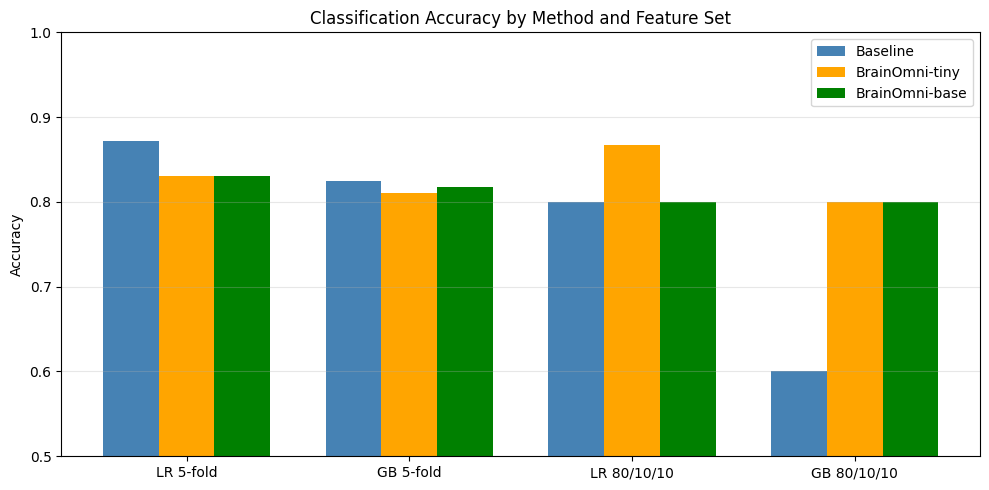

Saved accuracy_bar.png


In [9]:
import matplotlib.pyplot as plt
import numpy as np

methods    = ['LR 5-fold', 'GB 5-fold', 'LR 80/10/10', 'GB 80/10/10']
baseline_accs = [
    accuracy_score(y_true, y_pred_baseline),
    accuracy_score(y_true_gb, y_pred_baseline_gb),
    results_801010['Logistic Regression | Baseline'],
    results_801010['Gradient Boosting | Baseline'],
]
tiny_accs_bar = [
    accuracy_score(y_true, y_pred_tiny),
    accuracy_score(y_true_gb, y_pred_tiny_gb),
    results_801010['Logistic Regression | BrainOmni-tiny'],
    results_801010['Gradient Boosting | BrainOmni-tiny'],
]
base_accs_bar = [
    accuracy_score(y_true, y_pred_base),
    accuracy_score(y_true_gb, y_pred_base_gb),
    results_801010['Logistic Regression | BrainOmni-base'],
    results_801010['Gradient Boosting | BrainOmni-base'],
]

x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, baseline_accs, width, label='Baseline', color='steelblue')
ax.bar(x,         tiny_accs_bar, width, label='BrainOmni-tiny', color='orange')
ax.bar(x + width, base_accs_bar, width, label='BrainOmni-base', color='green')

ax.set_ylabel('Accuracy')
ax.set_title('Classification Accuracy by Method and Feature Set')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0.5, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/accuracy_bar.png', dpi=150)
plt.show()
print('Saved accuracy_bar.png')

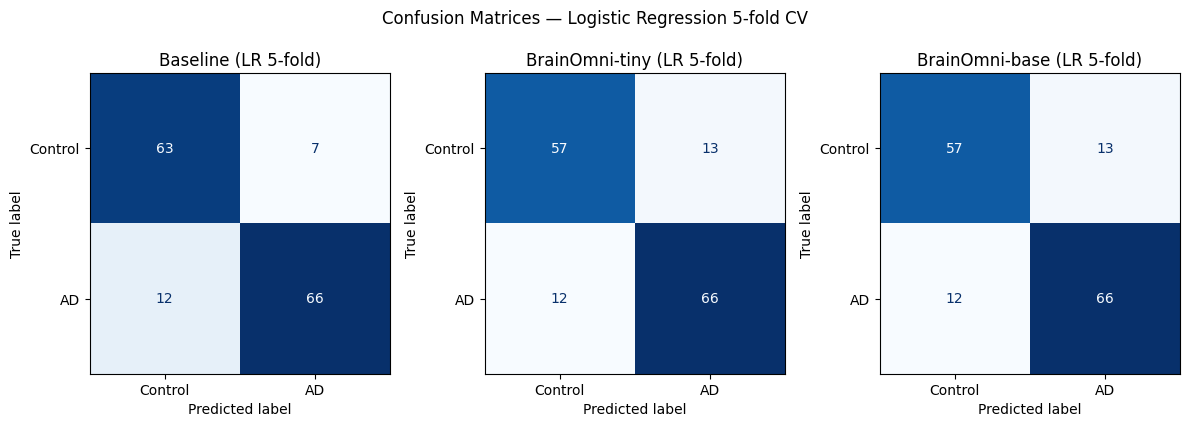

Saved confusion_matrices.png


In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

pairs = [
    ('Baseline (LR 5-fold)',        y_true, y_pred_baseline),
    ('BrainOmni-tiny (LR 5-fold)',  y_true, y_pred_tiny),
    ('BrainOmni-base (LR 5-fold)',  y_true, y_pred_base),
]

for ax, (title, yt, yp) in zip(axes, pairs):
    ConfusionMatrixDisplay.from_predictions(
        yt, yp,
        display_labels=['Control', 'AD'],
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )
    ax.set_title(title)

plt.suptitle('Confusion Matrices — Logistic Regression 5-fold CV', y=1.02)
plt.tight_layout()

plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved confusion_matrices.png')

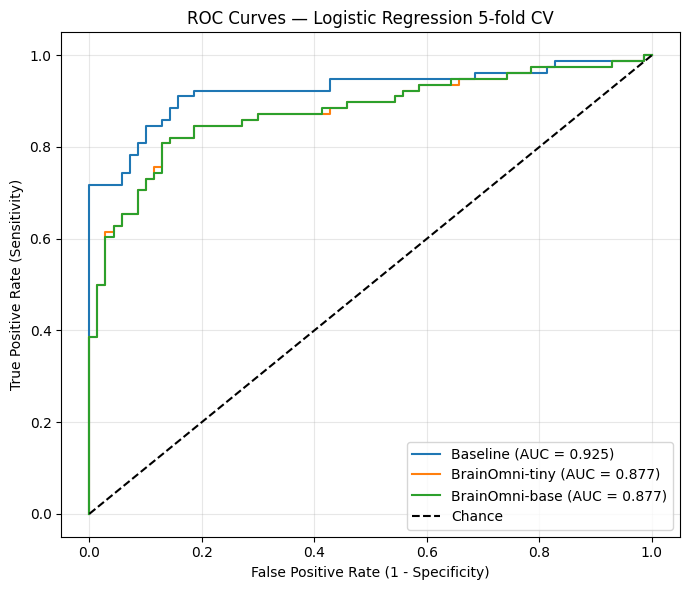

Saved roc_curves.png


In [11]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))

for name, proba in [
    ('Baseline',       proba_baseline),
    ('BrainOmni-tiny', proba_tiny),
    ('BrainOmni-base', proba_base),
]:
    fpr, tpr, _ = roc_curve(y_true_roc, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Chance')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curves — Logistic Regression 5-fold CV')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('/Users/faenegoro/Documents/Neuroimaging/meg_ad_project/results/figures/roc_curves.png', dpi=150)
plt.show()
print('Saved roc_curves.png')